<a href="https://colab.research.google.com/github/NadiiaIvashchuk/DTA_2026/blob/main/Stat%26Math/practice_stat_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [3]:
# Завдання 1:
df.describe()

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [4]:
# Завдання 2:
df.channel.value_counts()

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [5]:
# Завдання 3:
avg_session_min = df.session_min.mean()
print(f"Фактичне середнє: {avg_session_min:.1f} хв.")

t_stat, p_value = stats.ttest_1samp(df["session_min"], 20)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 20")
else:
    print("\n❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 20")

Фактичне середнє: 20.7 хв.
t-статистика: 1.570
p-значення:   0.1171

❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 20


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [6]:
# Завдання 4:
mean_spend = df["spend"].mean()
print(f"Фактичне середнє: {mean_spend:.1f} грн")

t_stat, p_value = stats.ttest_1samp(df["spend"], 850)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 850")
else:
    print("\n❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 850")

Фактичне середнє: 845.0 грн
t-статистика: -0.334
p-значення:   0.7384

❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 850


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [7]:
# Завдання 5:
spend_mobile = df[df["device"] == "Mobile"]["spend"]
spend_desktop = df[df["device"] == "Desktop"]["spend"]

print(f"Mobile:  {spend_mobile.mean():.1f} грн")
print(f"Desktop: {spend_desktop.mean():.1f} грн")

t_stat, p_value = stats.ttest_ind(spend_mobile, spend_desktop)
print(f"\np-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Значуща різниця між девайсами")
else:
    print("❌ Значущої різниці НЕ виявлено")

Mobile:  835.2 грн
Desktop: 861.2 грн

p-значення: 0.3993
❌ Значущої різниці НЕ виявлено


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [8]:
# Завдання 6:
spend_m = df[df["gender"] == "Ч"]["session_min"]
spend_f = df[df["gender"] == "Ж"]["session_min"]

print(f"Чоловіки: {spend_m.mean():.1f} хв.")
print(f"Жінки:    {spend_f.mean():.1f} хв.")

t_stat, p_value = stats.ttest_ind(spend_m, spend_f)
print(f"\np-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Значуща різниця між статями")
else:
    print("❌ Значущої різниці НЕ виявлено")

Чоловіки: 20.8 хв.
Жінки:    20.6 хв.

p-значення: 0.8163
❌ Значущої різниці НЕ виявлено


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [9]:
# Завдання 7:
print(f"Задоволеність ДО:    {df['sat_before'].mean():.2f}")
print(f"Задоволеність ПІСЛЯ: {df['sat_after'].mean():.2f}")

t_stat, p_value = stats.ttest_rel(df["sat_before"], df["sat_after"])
print(f"\np-значення: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Задоволеність значущо змінилася")
else:
    print("❌ Значущої зміни не виявлено")

Задоволеність ДО:    6.54
Задоволеність ПІСЛЯ: 7.14

p-значення: 0.000000
✅ Задоволеність значущо змінилася


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [10]:
# Завдання 8:
for channel in df["channel"].unique():
    avg = df[df["channel"] == channel]["spend"].mean()
    print(f"{channel}: {avg:.1f} грн")

groups = [df[df["channel"] == ch]["spend"] for ch in df["channel"].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-значення:   {p_value:.6f}")

if p_value < 0.05:
    print("✅ Принаймні один канал значущо відрізняється")
else:
    print("❌ Значущої різниці між каналами немає")

Реклама: 1057.9 грн
Органіка: 791.3 грн
Соцмережі: 698.4 грн

F-статистика: 63.54
p-значення:   0.000000
✅ Принаймні один канал значущо відрізняється


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [11]:
# Завдання 9:
for country in df["country"].unique():
    avg = df[df["country"] == country]["session_min"].mean()
    print(f"{channel}: {avg:.1f} хв.")

groups = [df[df["country"] == ch]["session_min"] for ch in df["country"].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-значення:   {p_value:.6f}")

if p_value < 0.05:
    print("✅ Принаймні для однієї країни значущо відрізняється")
else:
    print("❌ Значущої різниці між країнами немає")

Соцмережі: 21.3 хв.
Соцмережі: 20.3 хв.
Соцмережі: 21.2 хв.

F-статистика: 0.49
p-значення:   0.611082
❌ Значущої різниці між країнами немає


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [12]:
# Завдання 10:
contingency = pd.crosstab(df["channel"], df["purchased"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Канал ПОВ'ЯЗАНИЙ із покупкою")
else:
    print("❌ Зв'язку не виявлено")

Таблиця спряженості:
purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

chi2: 0.957
p-значення: 0.6198
❌ Зв'язку не виявлено


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [13]:
# Завдання 11:
contingency = pd.crosstab(df["device"], df["gender"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Тип девайсу ПОВ'ЯЗАНИЙ із статтю покупця")
else:
    print("❌ Зв'язку не виявлено")

Таблиця спряженості:
gender     Ж    Ч
device           
Desktop   93   96
Mobile   158  153

chi2: 0.065
p-значення: 0.7993
❌ Зв'язку не виявлено


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Коефіцієнт кореляції r: 0.732
p-значення: 0.000000
✅ Зв'язок статистично значущий


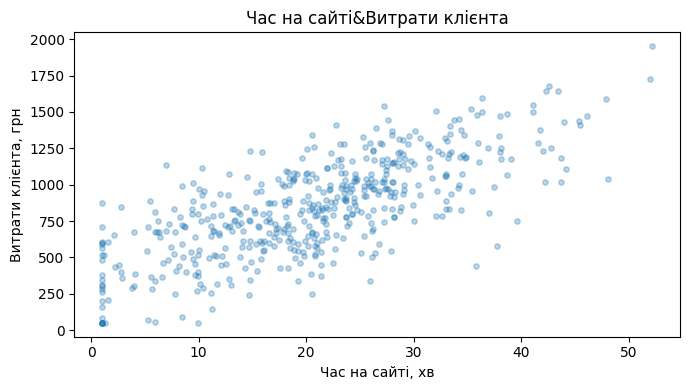

In [14]:
# Завдання 12:
r, p_value = stats.pearsonr(df["session_min"], df["spend"])
print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.6f}")

# r близький до 1 → сильний прямий зв'язок; до 0 → зв'язку немає
if p_value < 0.05:
    print("✅ Зв'язок статистично значущий")
else:
    print("❌ Значущого зв'язку немає")

plt.figure(figsize=(7, 4))
plt.scatter(df['session_min'], df['spend'], alpha=0.3, s=15)
plt.xlabel('Час на сайті, хв')
plt.ylabel("Витрати клієнта, грн")
plt.title("Час на сайті&Витрати клієнта")
plt.tight_layout()
plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [15]:
# Завдання 13:
r, p_value = stats.pearsonr(df["age"], df["spend"])
print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.6f}")

# r близький до 1 → сильний прямий зв'язок; до 0 → зв'язку немає
if p_value < 0.05:
    print("✅ Зв'язок статистично значущий")
else:
    print("❌ Значущого зв'язку немає")

Коефіцієнт кореляції r: -0.042
p-значення: 0.350752
❌ Значущого зв'язку немає


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [16]:
# Завдання 14:
ab.group.value_counts()

,count
group,
A,4000
B,4000


In [17]:
ab.head()

,session_id,group,converted
0,1392,A,0
1,118,A,0
2,1295,A,0
3,4354,B,1
4,3476,A,1


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [18]:
# Завдання 15:
print(
    f"Конверсія відрізняється на "
    f"{100 * (ab.groupby('group')['converted'].mean()['B'] - ab.groupby('group')['converted'].mean()['A']):.2f} в.п."
)


Конверсія відрізняється на 1.80 в.п.


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [19]:
# Завдання 16:
contingency = pd.crosstab(ab["group"], ab["converted"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Версія ПОВ'ЯЗАНА з покупкою")
else:
    print("❌ Зв'язку не виявлено")

Таблиця спряженості:
converted     0    1
group               
A          3596  404
B          3524  476

chi2: 6.436
p-значення: 0.0112
✅ Версія ПОВ'ЯЗАНА з покупкою


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*ANOVA*

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [20]:
# Завдання 17:
for channel in df["channel"].unique():
    avg = df[df["channel"] == channel]["age"].mean()
    print(f"{channel}: {avg:.0f} років")

groups = [df[df["channel"] == ch]["age"] for ch in df["channel"].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-значення:   {p_value:.6f}")

if p_value < 0.05:
    print("✅ Принаймні один канал значущо відрізняється")
else:
    print("❌ Значущої різниці між каналами немає")

Реклама: 35 років
Органіка: 34 років
Соцмережі: 34 років

F-статистика: 0.60
p-значення:   0.549838
❌ Значущої різниці між каналами немає


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*t-тест (для одної вибірки)*

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [21]:
# Завдання 18:
mean_spend = df["spend"].mean()
print(f"Фактичне середнє: {mean_spend:.1f} грн")

t_stat, p_value = stats.ttest_1samp(df["spend"], 900)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 900")
else:
    print("\n❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 900")

Фактичне середнє: 845.0 грн
t-статистика: -3.687
p-значення:   0.0003

✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 900


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Хі-квадрат*

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [22]:
# Завдання 19:
contingency = pd.crosstab(df["country"], df["device"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Вибір девайса ПОВ'ЯЗАНИЙ з країною")
else:
    print("❌ Зв'язку не виявлено")

Таблиця спряженості:
device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166

chi2: 1.207
p-значення: 0.5470
❌ Зв'язку не виявлено


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Кореляційний тест (Пірсона)*

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [23]:
# Завдання 20:
r, p_value = stats.pearsonr(df["age"], df["session_min"])
print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.6f}")

# r близький до 1 → сильний прямий зв'язок; до 0 → зв'язку немає
if p_value < 0.05:
    print("✅ Зв'язок статистично значущий")
else:
    print("❌ Значущого зв'язку немає")

Коефіцієнт кореляції r: -0.012
p-значення: 0.789823
❌ Значущого зв'язку немає


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
